In [16]:
import sys
import os

PROJECT_ROOT = r"F:\AssignGuard"

if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)
    
print(PROJECT_ROOT)

F:\AssignGuard


## Imports


In [17]:
from src.preprocessing import preprocess_document
from src.similarity import tfidf_similarity, jaccard_similarity
from src.evaluation import evaluate_model
from src.visualization import visualize, rank_suspicious_pairs, plot_clusters
from src.clustering import reduce_dimensions, plot_pca, perform_dbscan

import os
import pandas as pd

os.makedirs("notebook/results", exist_ok=True)

## Load Dataset

In [18]:
os.chdir(PROJECT_ROOT)
path = "./data/raw"

file_paths = []

for root, _, files in os.walk(path):
    for f in files:
        if f.endswith(".txt"):
            file_paths.append(os.path.join(root, f))

file_paths.sort()

doc_names = [
os.path.basename(file_path)
for file_path in file_paths
]

print(f"Documents Loaded: {len(doc_names)}")

Documents Loaded: 40


## Preprocessing

In [19]:
documents = [
preprocess_document(file_path)
for file_path in file_paths
]

print("Preprocessing Complete")

Preprocessing Complete


## TF-IDF

In [20]:
tfidf_matrix, tfidf_vectors = tfidf_similarity(documents)
print("TF-IDF Similarity Matrix Generated")

TF-IDF Similarity Matrix Generated


## Jaccard

In [21]:
jaccard_matrix = jaccard_similarity(documents)

print("Jaccard Similarity Matrix Generated")

Jaccard Similarity Matrix Generated


## Evaluation

In [22]:
results_tfidf = evaluate_model(
    tfidf_matrix,
    doc_names,
    "./data/labels/pairs.csv",
    threshold=0.70
)

results_jaccard = evaluate_model(
    jaccard_matrix,
    doc_names,
    "./data/labels/pairs.csv",
    threshold=0.70
)

Threshold: 0.7
Precision: 1.00
Recall: 1.00
F1 Score: 1.00
Threshold: 0.7
Precision: 1.00
Recall: 1.00
F1 Score: 1.00


## Suspicious Pairs

In [23]:
pairs = rank_suspicious_pairs(
    tfidf_matrix,
    doc_names,
    threshold=0.70
)

pairs

,Document 1,Document 2,Similarity Score
0,cc_copy_01.txt,cc_orig_01.txt,0.91
1,cc_copy_02.txt,cc_orig_02.txt,0.91
2,nw_copy_02.txt,nw_orig_02.txt,0.89
3,db_copy_01.txt,db_orig_01.txt,0.86
4,db_copy_02.txt,db_orig_02.txt,0.85
5,ml_copy_01.txt,ml_orig_01.txt,0.84
6,nw_copy_01.txt,nw_orig_01.txt,0.80
7,ml_copy_02.txt,ml_orig_02.txt,0.78
8,cs_copy_01.txt,cs_orig_01.txt,0.78
9,cc_copy_02.txt,cc_para_02.txt,0.76


## Heatmap

In [24]:
print(os.getcwd())

F:\AssignGuard


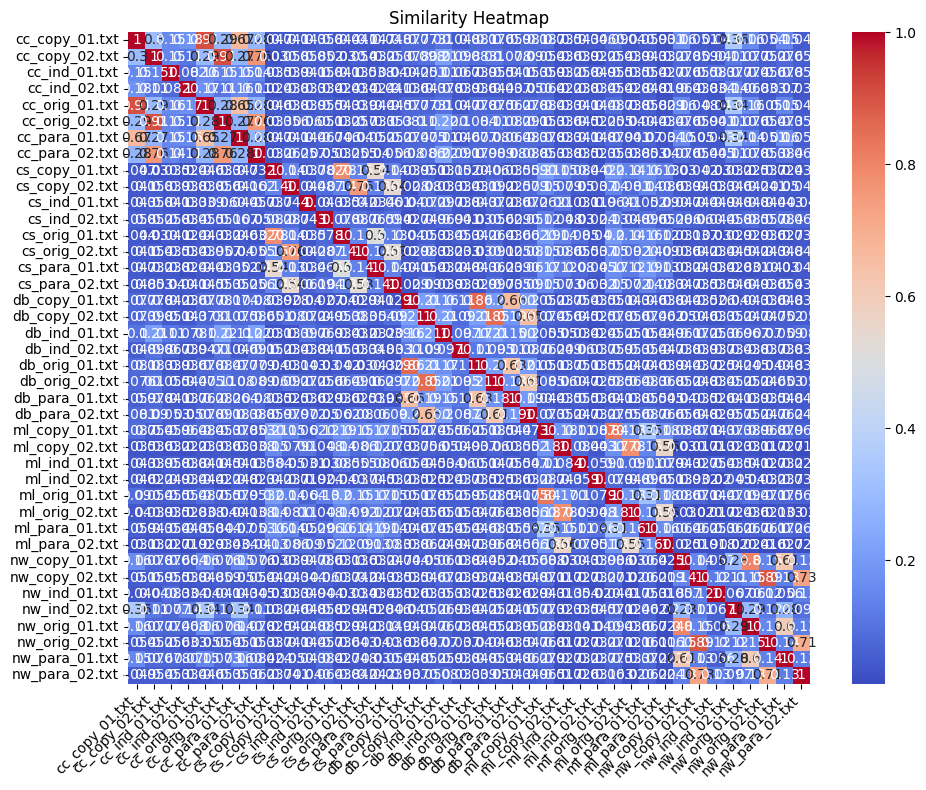

In [25]:
heatmap_fig = visualize(
    tfidf_matrix,
    doc_names,
    save_path="notebook/results/heatmap.png"
)

## PCA Plot|

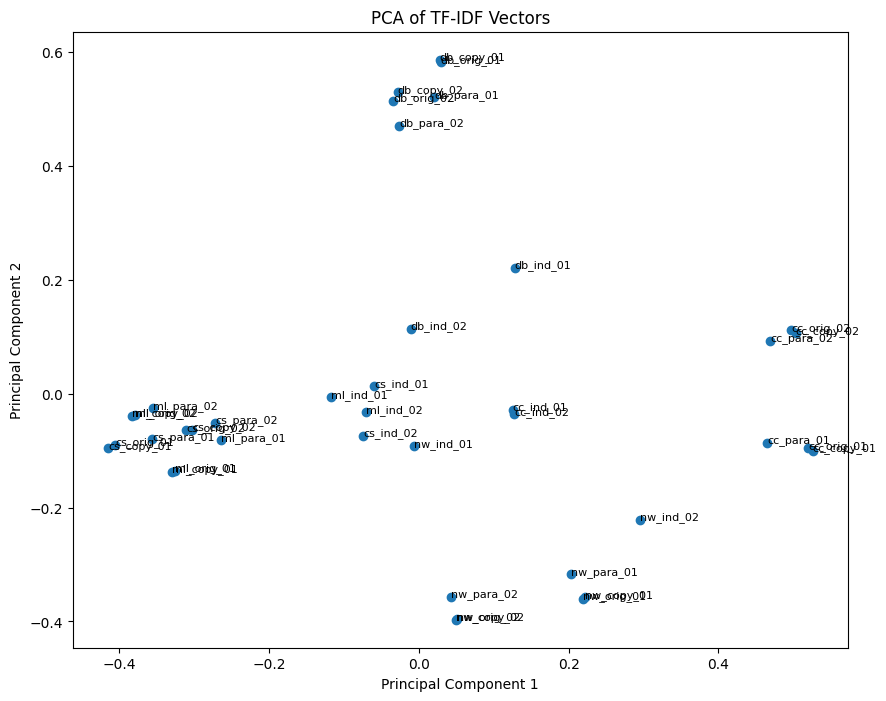

In [26]:
reduced_vectors = reduce_dimensions(
    tfidf_vectors
)

pca_fig = plot_pca(
    reduced_vectors,
    doc_names,
    save_path="notebook/results/pca.png"
)


## Cluster Table

In [33]:
cluster_labels = perform_dbscan(
    tfidf_vectors,
    eps=0.8,
    min_samples=2
)

Silhouette Score: 0.212


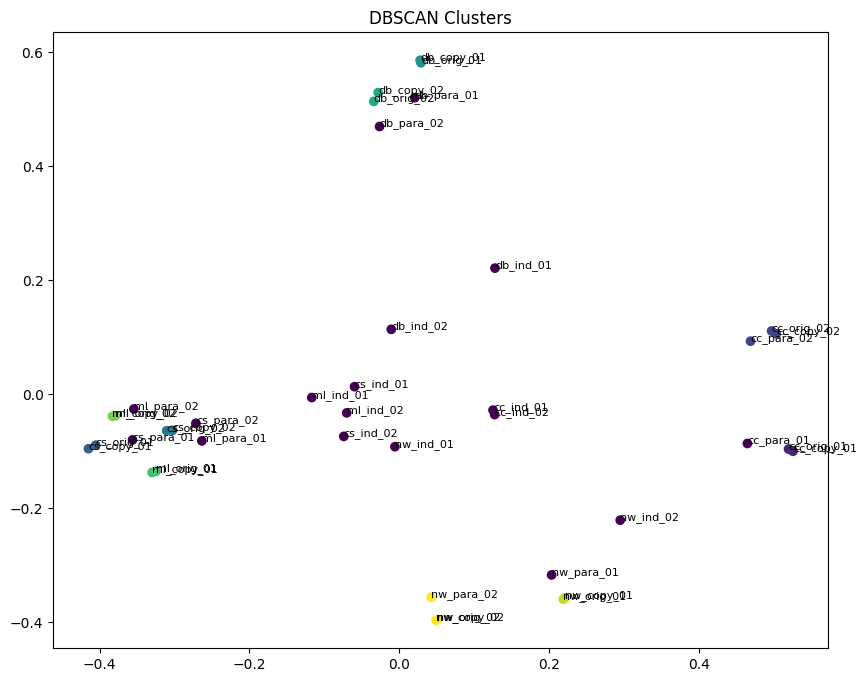

In [34]:
cluster_fig = plot_clusters(
    reduced_vectors,
    cluster_labels,
    doc_names,
    save_path="notebook/results/clusters.png"
)

In [35]:

cluster_df = pd.DataFrame({
    "Document": doc_names,
    "Cluster": cluster_labels
})

cluster_df.to_csv(
    "notebook/results/clusters.csv",
    index=False
)

cluster_df

,Document,Cluster
0,cc_copy_01.txt,0
1,cc_copy_02.txt,1
2,cc_ind_01.txt,-1
3,cc_ind_02.txt,-1
4,cc_orig_01.txt,0
5,cc_orig_02.txt,1
6,cc_para_01.txt,-1
7,cc_para_02.txt,1
8,cs_copy_01.txt,2
9,cs_copy_02.txt,3
